<a href="https://colab.research.google.com/github/nursyafiigit/UAS_syafii_23_11_5451/blob/main/UAS_syafii_23_11_5451.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FINAL PROJECT – BIG DATA & DATA MINING**
## **Prediksi Harga Rumah (California Housing Dataset)**

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

## 2. Memuat Dataset (Dataset Publik)

In [2]:
# Mengambil dataset California Housing dari Scikit-Learn
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

print(f"Dataset dimuat dengan {df.shape[0]} baris dan {df.shape[1]} kolom.")
df.head()

Dataset dimuat dengan 20640 baris dan 9 kolom.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [9]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [10]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


## 3. Exploratory Data Analysis (EDA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


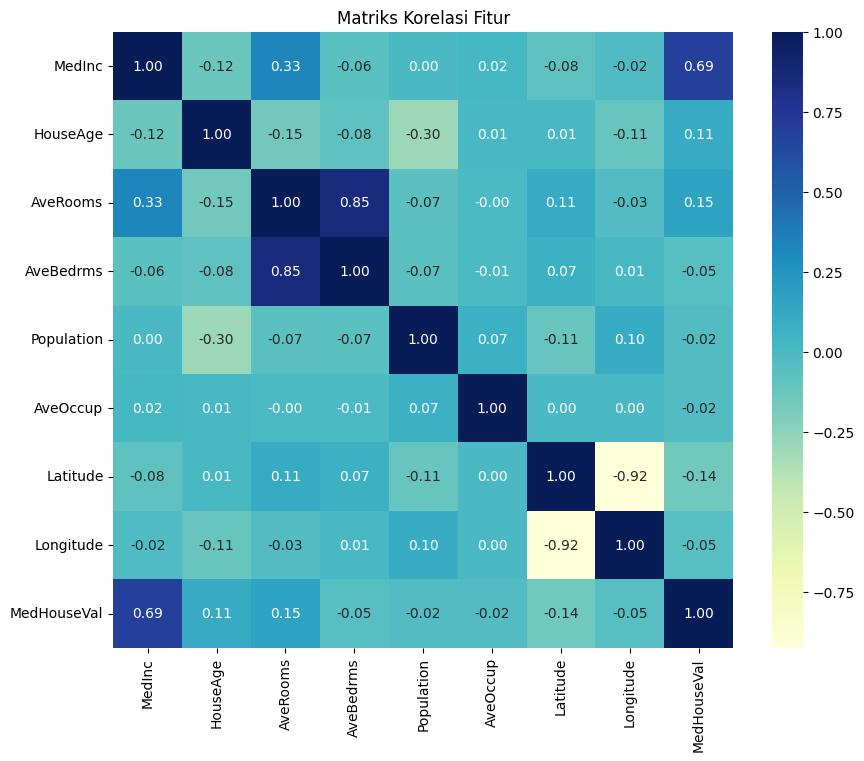

In [3]:
# Informasi dataset
print(df.info())

# Matriks Korelasi untuk melihat hubungan antar fitur
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Matriks Korelasi Fitur')
plt.show()

## 4. Preprocessing Data

In [4]:
# Memisahkan Fitur (X) dan Target (y)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scalling Fitur agar model bekerja lebih maksimal
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing selesai: Data telah di-split dan di-scaling.")

Preprocessing selesai: Data telah di-split dan di-scaling.


## 5. Pemodelan (Predictive Analytics - Regression)

In [5]:
# Inisialisasi Model
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Training
lr.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)

print("Model Linear Regression dan Random Forest telah dilatih.")

Model Linear Regression dan Random Forest telah dilatih.


## 6. Evaluasi Model (Metrics Evaluation)

In [6]:
def evaluate(model, X_test, y_test, name):
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print(f"[{name}] MAE: {mae:.4f}, R2 Score: {r2:.4f}")

evaluate(lr, X_test_scaled, y_test, "Linear Regression")
evaluate(rf, X_test_scaled, y_test, "Random Forest")

[Linear Regression] MAE: 0.5332, R2 Score: 0.5758
[Random Forest] MAE: 0.3274, R2 Score: 0.8053


## 7. Simpan Model

In [7]:
joblib.dump(rf, 'model_perumahan_california.pkl')
print("Model terbaik (Random Forest) berhasil disimpan.")

Model terbaik (Random Forest) berhasil disimpan.


Berdasarkan proses data mining yang telah dilakukan menggunakan California Housing Dataset sebagai dataset publik, dapat disimpulkan bahwa seluruh tahapan data mining telah diterapkan secara sistematis, mulai dari tahap data understanding, exploratory data analysis (EDA), preprocessing, pembangunan model, hingga evaluasi performa model.

Pendekatan yang digunakan dalam penelitian ini adalah Predictive Analytics dengan metode regresi, yang bertujuan untuk memprediksi nilai median harga rumah berdasarkan beberapa variabel independen yang tersedia dalam dataset. Dua model regresi, yaitu Linear Regression dan Random Forest Regression, telah dibangun dan dievaluasi menggunakan metrik Mean Absolute Error (MAE) dan R-Squared (R²).

Hasil evaluasi menunjukkan bahwa Random Forest Regression memberikan performa yang lebih baik dibandingkan dengan Linear Regression, ditunjukkan oleh nilai kesalahan prediksi yang lebih rendah serta nilai R² yang lebih tinggi. Hal ini mengindikasikan bahwa model Random Forest mampu menangkap hubungan nonlinier antar variabel dengan lebih baik dalam memprediksi harga rumah.

Dengan demikian, dapat disimpulkan bahwa penerapan metode data mining dalam penelitian ini telah berhasil memenuhi tujuan analisis, serta model yang dihasilkan dapat digunakan sebagai dasar dalam pengambilan keputusan berbasis data terkait prediksi harga rumah. Penelitian ini juga menunjukkan pentingnya pemilihan model yang tepat untuk meningkatkan akurasi prediksi pada permasalahan regresi.